In [119]:
import pandas as pd
import matplotlib.pyplot as plt

In [120]:
model_name = "qwen4b-ft"

In [121]:
model_name = "qwen4b"
#gt1_context = pd.read_csv(f'Result/{model_name}/giai_tich_1_with_context.csv')
gt1 = pd.read_csv(f"Result/{model_name}/giải_tích_1_no_context.csv")
ds_context = pd.read_csv(f'Result/{model_name}/dai_so_with_context.csv')
ds = pd.read_csv(f"Result/{model_name}/dai_so_no_context.csv")
gt_lt = pd.read_csv(f"Result/{model_name}/giai_tich_1_ly_thuyet.csv")
ds_lt = pd.read_csv(f"Result/{model_name}/dai_so_ly_thuyet.csv")

for df_name in ["gt1", "ds_context", "ds", "gt_lt", "ds_lt"]:
    locals()[df_name] = locals()[df_name].drop("id", axis=1)

In [122]:
model_name = "qwen4b-ft"
gt1_context_ft = pd.read_csv(f'Result/{model_name}/giai_tich_1_with_context.csv')
gt1_ft = pd.read_csv(f"Result/{model_name}/giai_tich_1_no_context.csv")
ds_context_ft = pd.read_csv(f'Result/{model_name}/dai_so_with_context.csv')
ds_ft = pd.read_csv(f"Result/{model_name}/dai_so_no_context.csv")
gt_lt_ft = pd.read_csv(f"Result/{model_name}/giai_tich_1_ly_thuyet.csv")
ds_lt_ft = pd.read_csv(f"Result/{model_name}/dai_so_ly_thuyet.csv")

for df_name in ["gt1_context_ft", "gt1_ft", "ds_context_ft", "ds_ft", "gt_lt_ft", "ds_lt_ft"]:
    locals()[df_name] = locals()[df_name].drop("id", axis=1)

In [123]:
import pandas as pd
import matplotlib.pyplot as plt

def create_chart(means):
    mean_df = pd.DataFrame(means)
    # Vẽ đường
    ax = mean_df.plot(kind="line", marker="o", figsize=(12, 6))
    plt.title("So sánh giữa các dataframe")
    plt.ylabel("Giá trị trung bình")
    # Buộc hiển thị đủ tất cả chỉ mục
    plt.xticks(range(len(mean_df.index)), mean_df.index, rotation=45)
    plt.legend(title="DataFrames")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

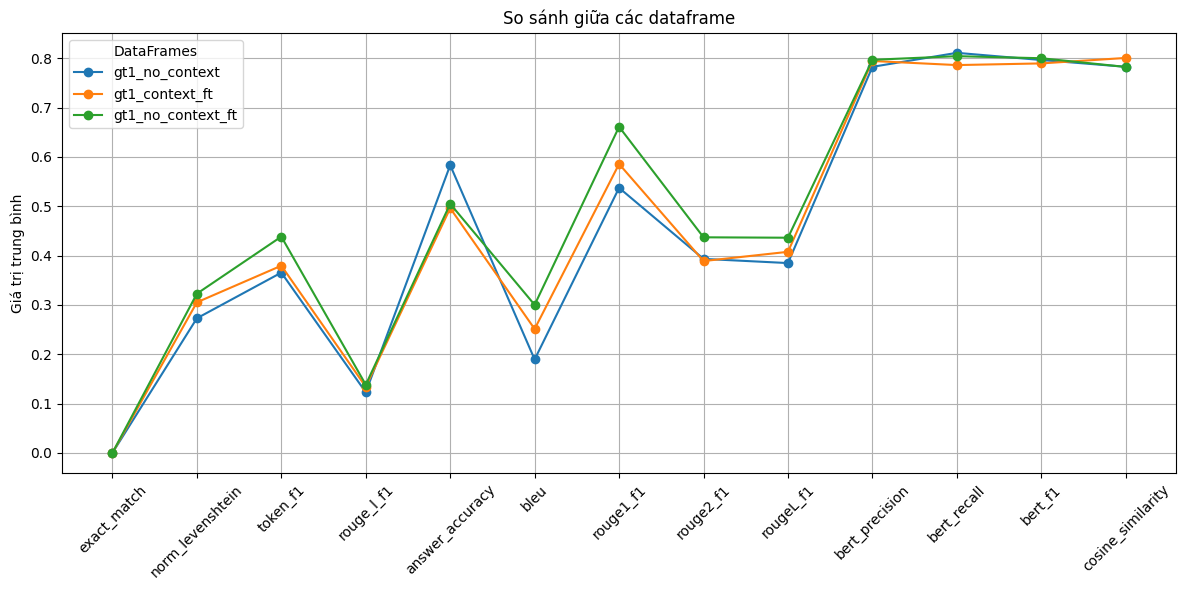

In [124]:
means = {
    "gt1_no_context": gt1.mean(),
    "gt1_context_ft": gt1_context_ft.mean(),
    "gt1_no_context_ft": gt1_ft.mean()
}
create_chart(means)

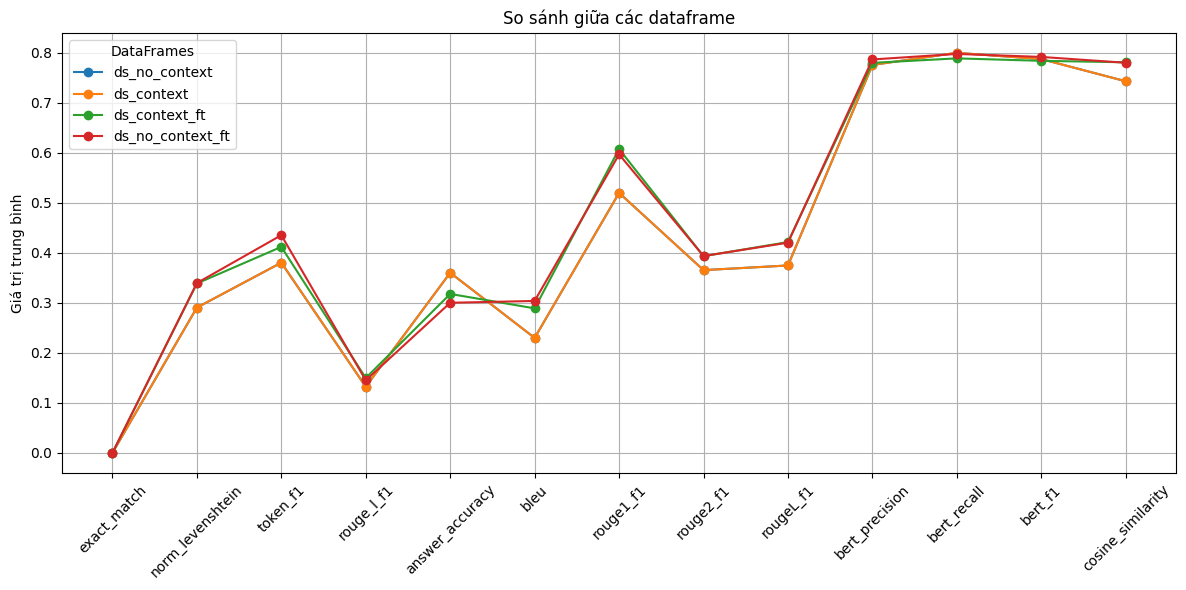

In [125]:
means = {
    "ds_no_context": ds.mean(),
    "ds_context": ds_context.mean(),
    "ds_context_ft": ds_context_ft.mean(),
    "ds_no_context_ft": ds_ft.mean()
}
create_chart(means)

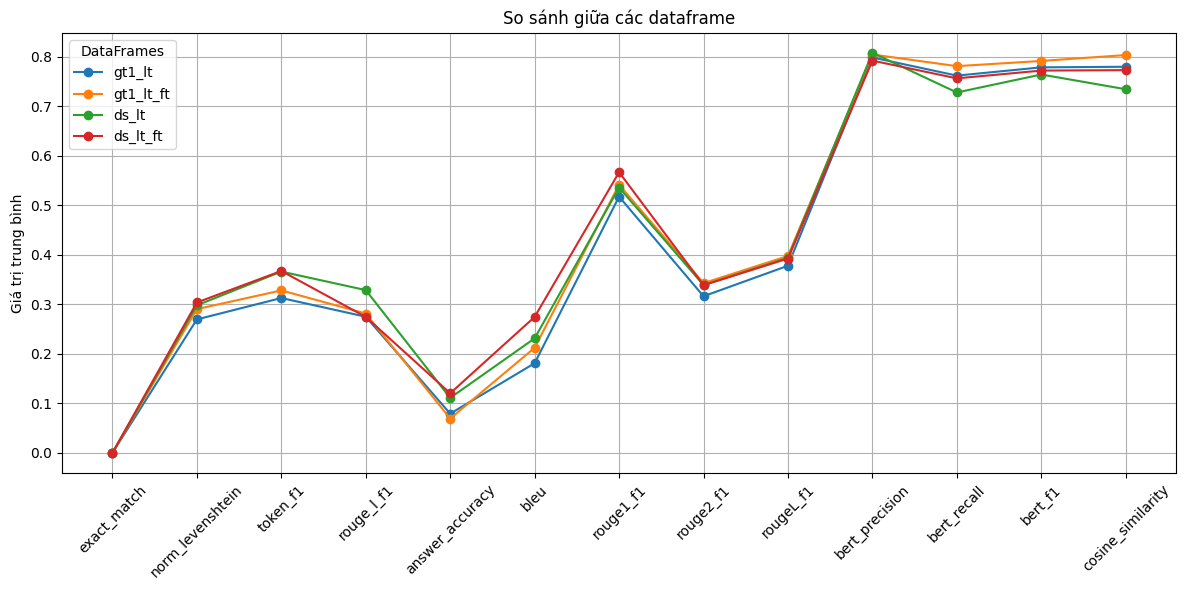

In [126]:
means = {
    "gt1_lt": gt_lt.mean(),
    "gt1_lt_ft": gt_lt_ft.mean(),
    "ds_lt": ds_lt.mean(),
    "ds_lt_ft": ds_lt_ft.mean()
}
create_chart(means)

🚀 Bắt đầu xử lý dữ liệu...
📊 Đang ghép dữ liệu bài tập...
📚 Đang ghép dữ liệu lý thuyết...
🎨 Đang vẽ biểu đồ...


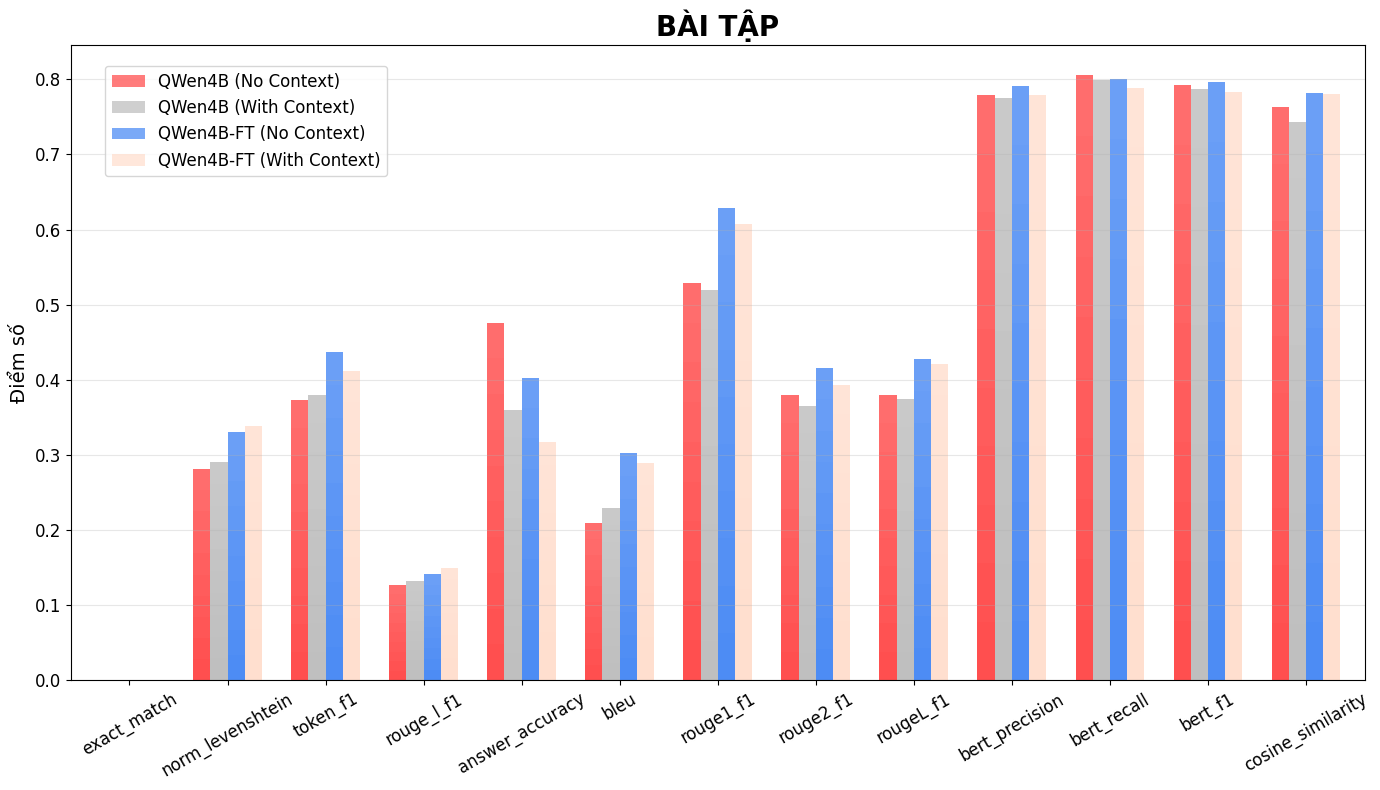

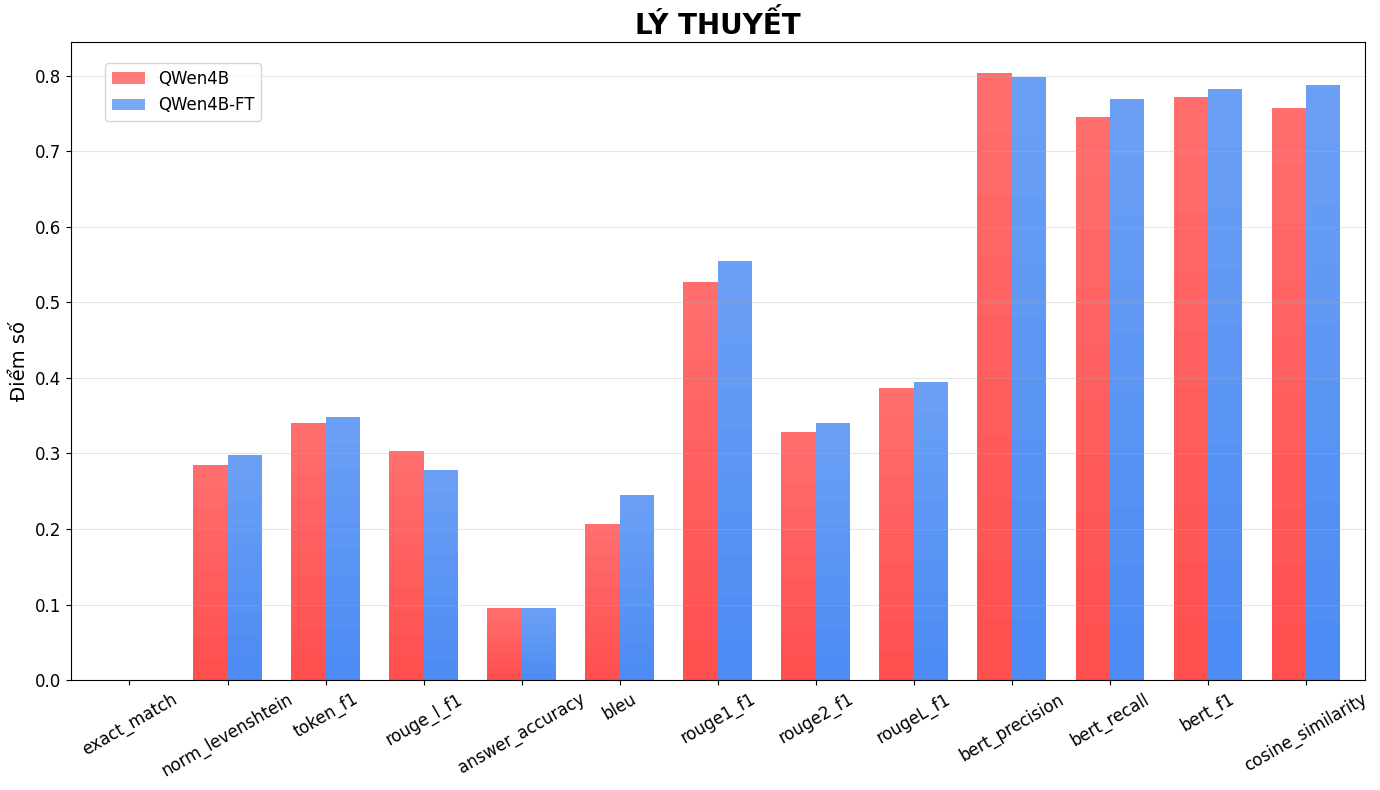

✅ Hoàn thành biểu đồ!

🔥 THỐNG KÊ NHANH:

📊 BÀI TẬP - Top 3 Metrics:
   bert_recall: 0.7986
   bert_f1: 0.7896
   bert_precision: 0.7814

📚 LÝ THUYẾT - Top 3 Metrics:
   bert_precision: 0.8012
   bert_f1: 0.7767
   cosine_similarity: 0.7724

📈 KẾT QUẢ NHANH:
   Fine-tuning cải thiện Bài tập: +6.1%
   Fine-tuning cải thiện Lý thuyết: +2.6%

🎯 DONE! Biểu đồ đã sẵn sàng!


In [127]:
# So sánh tổng hợp giữa 2 model - PHIÊN BẢN TỐI ƯU
print("🚀 Bắt đầu xử lý dữ liệu...")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# === GHÉP DỮ LIỆU NHANH ===
print("📊 Đang ghép dữ liệu bài tập...")
bai_tap_4b_no = pd.concat([gt1, ds], ignore_index=True).mean()
bai_tap_4b_context = ds_context.mean()  
bai_tap_4b_ft_no = pd.concat([gt1_ft, ds_ft], ignore_index=True).mean()
bai_tap_4b_ft_context = ds_context_ft.mean()

print("📚 Đang ghép dữ liệu lý thuyết...")
ly_thuyet_4b = pd.concat([gt_lt, ds_lt], ignore_index=True).mean()
ly_thuyet_4b_ft = pd.concat([gt_lt_ft, ds_lt_ft], ignore_index=True).mean()

# === TẠO DATAFRAME ĐƠN GIẢN ===
bai_tap_data = pd.DataFrame({
    'QWen4B (No Context)': bai_tap_4b_no,
    'QWen4B (With Context)': bai_tap_4b_context,
    'QWen4B-FT (No Context)': bai_tap_4b_ft_no,
    'QWen4B-FT (With Context)': bai_tap_4b_ft_context
})

ly_thuyet_data = pd.DataFrame({
    'QWen4B': ly_thuyet_4b,
    'QWen4B-FT': ly_thuyet_4b_ft
})

print("🎨 Đang vẽ biểu đồ...")

# === HÀM TẠO GRADIENT ===
def create_gradient_bars(ax, data, colors, alpha=0.8):
    """Tạo các cột với gradient màu"""
    x_pos = np.arange(len(data.index))
    width = 0.18
    
    for i, (col_name, col_data) in enumerate(data.items()):
        # Vị trí của cột
        x = x_pos + (i - len(data.columns)/2 + 0.5) * width
        
        # Tạo gradient cho mỗi cột
        for j, (idx, height) in enumerate(col_data.items()):
            # Tạo gradient từ màu đậm ở dưới đến màu nhạt ở trên
            color = colors[i]
            
            # Vẽ cột với gradient
            bars = ax.bar(x[j], height, width, alpha=alpha, color=color, 
                         label=col_name if j == 0 else "")
            
            # Tạo hiệu ứng gradient bằng cách vẽ nhiều lớp mỏng
            for k in range(20):
                y_bottom = height * k / 20
                y_height = height / 20
                alpha_grad = alpha * (1 - k/30)  # Gradient alpha
                ax.bar(x[j], y_height, width, bottom=y_bottom, 
                      alpha=alpha_grad, color=color)

# === VẼ BIỂU ĐỒ RIÊNG BIỆT ===

# Biểu đồ bài tập với gradient
fig, ax = plt.subplots(figsize=(14, 8))

# Màu sắc gradient
colors = ['#FF4444', '#BBBBBB', '#4285F4', '#FFDDCC']

# Vẽ biểu đồ thông thường trước
bars = bai_tap_data.plot(kind='bar', ax=ax, width=0.7, alpha=0.7, 
                        color=colors)

# Thêm hiệu ứng gradient lên trên
for i, (col_name, col_data) in enumerate(bai_tap_data.items()):
    bars_container = ax.containers[i]
    for j, bar in enumerate(bars_container):
        # Lấy vị trí và kích thước cột
        x, y, width, height = bar.get_x(), bar.get_y(), bar.get_width(), bar.get_height()
        
        # Tạo gradient từ đậm đến nhạt
        for k in range(10):
            y_pos = height * k / 10
            rect_height = height / 10
            alpha_val = 0.8 - (k * 0.06)  # Giảm dần alpha
            
            gradient_bar = plt.Rectangle((x, y + y_pos), width, rect_height, 
                                       facecolor=colors[i], alpha=alpha_val)
            ax.add_patch(gradient_bar)

ax.set_title('BÀI TẬP', fontsize=20, fontweight='bold')
ax.set_ylabel('Điểm số', fontsize=14)

# === Legend đặt vào trong biểu đồ ===
ax.legend(loc="upper left", bbox_to_anchor=(0.02, 0.98), fontsize=12, frameon=True)

ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=30, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.tight_layout()
plt.show()

# Biểu đồ lý thuyết với gradient
fig, ax = plt.subplots(figsize=(14, 8))

# Màu cho lý thuyết
lt_colors = ['#FF4444', '#4285F4']

# Vẽ biểu đồ thông thường
bars_lt = ly_thuyet_data.plot(kind='bar', ax=ax, width=0.7, alpha=0.7,
                             color=lt_colors)

# Thêm hiệu ứng gradient
for i, (col_name, col_data) in enumerate(ly_thuyet_data.items()):
    bars_container = ax.containers[i]
    for j, bar in enumerate(bars_container):
        x, y, width, height = bar.get_x(), bar.get_y(), bar.get_width(), bar.get_height()
        
        for k in range(10):
            y_pos = height * k / 10
            rect_height = height / 10
            alpha_val = 0.8 - (k * 0.06)
            
            gradient_bar = plt.Rectangle((x, y + y_pos), width, rect_height, 
                                       facecolor=lt_colors[i], alpha=alpha_val)
            ax.add_patch(gradient_bar)

ax.set_title('LÝ THUYẾT', fontsize=20, fontweight='bold')
ax.set_ylabel('Điểm số', fontsize=14)

# === Legend đặt vào trong biểu đồ ===
ax.legend(loc="upper left", bbox_to_anchor=(0.02, 0.98), fontsize=12, frameon=True)

ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=30, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.tight_layout()
plt.show()

print("✅ Hoàn thành biểu đồ!")

# === THỐNG KÊ NHANH ===
print("\n🔥 THỐNG KÊ NHANH:")
print("=" * 50)

print("\n📊 BÀI TẬP - Top 3 Metrics:")
top_metrics_bt = bai_tap_data.mean(axis=1).nlargest(3)
for metric, score in top_metrics_bt.items():
    print(f"   {metric}: {score:.4f}")

print("\n📚 LÝ THUYẾT - Top 3 Metrics:")
top_metrics_lt = ly_thuyet_data.mean(axis=1).nlargest(3)
for metric, score in top_metrics_lt.items():
    print(f"   {metric}: {score:.4f}")

# === SO SÁNH NHANH ===
print("\n📈 KẾT QUẢ NHANH:")
bt_improvement = ((bai_tap_data['QWen4B-FT (No Context)'].sum() - bai_tap_data['QWen4B (No Context)'].sum()) / bai_tap_data['QWen4B (No Context)'].sum() * 100)
lt_improvement = ((ly_thuyet_data['QWen4B-FT'].sum() - ly_thuyet_data['QWen4B'].sum()) / ly_thuyet_data['QWen4B'].sum() * 100)

print(f"   Fine-tuning cải thiện Bài tập: {bt_improvement:+.1f}%")
print(f"   Fine-tuning cải thiện Lý thuyết: {lt_improvement:+.1f}%")

print("\n🎯 DONE! Biểu đồ đã sẵn sàng!")